# **Day 44: Interpretability I - Permutation Importance, PDP, ICE and ALE**
*Module 7 - Model Selection, Tuning and Explainability*

An accurate black box is often not enough. Scientists need to know **which drivers matter and how**; regulators need explanations; and explanations expose bugs and leakage. Today: **global, model-agnostic** methods that work for any model.

> Interpretability tools explain what a model has learned. Permutation importance measures how much accuracy drops when a feature is shuffled. PDP, ICE and ALE plots show how predictions change as one feature changes.
>
> *Example:* Shuffling the slope values and seeing landslide AUC drop from 0.85 to 0.65 shows that the model relies heavily on slope.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay, partial_dependence
rng = np.random.default_rng(44)

## **1. A Dataset With Known Truth**
Simulated forest above-ground biomass (AGB): we **know** the true effects, so we can check whether the explanation methods recover them.
- NDVI: strong, saturating effect
- Rainfall: hump-shaped (too much rain -> waterlogging)
- Elevation x temperature: **interaction** (temperature matters only at low elevation)
- Canopy height and NDVI are **correlated** (as in reality)
- One pure-noise feature

In [2]:
n = 3000
ndvi = rng.uniform(0.1, 0.9, n)
canopy_h = 30 * ndvi + rng.normal(0, 3, n)                         # correlated with NDVI
rain = rng.uniform(500, 3500, n)
elev = rng.uniform(0, 2500, n)
temp = 30 - 0.006 * elev + rng.normal(0, 2, n)
noise = rng.normal(size=n)
agb = (200 * (1 - np.exp(-4 * ndvi)) + 3 * canopy_h - 30 * ((rain - 2000) / 1000) ** 2
       + np.where(elev < 1000, 4 * (temp - 25), 0) + rng.normal(0, 10, n))
X = pd.DataFrame({"ndvi": ndvi, "canopy_h": canopy_h, "rain": rain, "elev": elev, "temp": temp, "noise": noise})
X_tr, X_te, y_tr, y_te = train_test_split(X, agb, test_size=0.3, random_state=0)
model = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, random_state=0).fit(X_tr, y_tr)
print(f"test R2 = {model.score(X_te, y_te):.3f}")

test R2 = 0.967


## **2. Permutation Importance**
Shuffle one feature in the **test** set and measure how much the score drops. Repeat for uncertainty. Measures how much the **model relies** on a feature (not necessarily how important it is in reality).

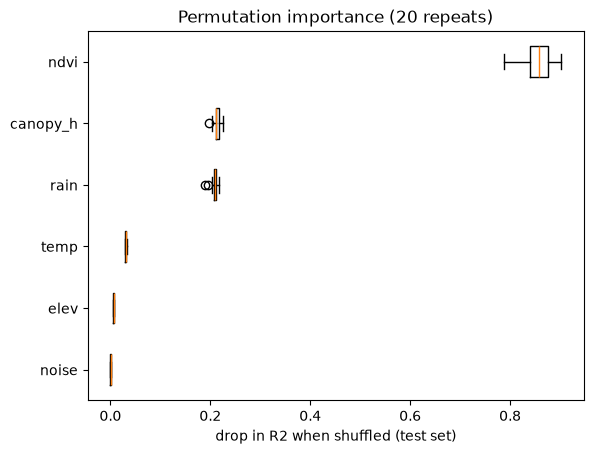

In [3]:
pi = permutation_importance(model, X_te, y_te, n_repeats=20, random_state=0, scoring="r2", n_jobs=-1)
order = pi.importances_mean.argsort()
plt.boxplot(pi.importances[order].T, vert=False, tick_labels=X.columns[order])
plt.xlabel("drop in R2 when shuffled (test set)"); plt.title("Permutation importance (20 repeats)"); plt.show()

## **3. Partial Dependence Plots**
$$\text{PD}_j(x) = \frac1n\sum_{i=1}^n \hat f(x, \mathbf x_{i,-j})$$
Set feature $j$ to $x$ for **every** sample, predict, and average. The curve shows the average marginal effect.

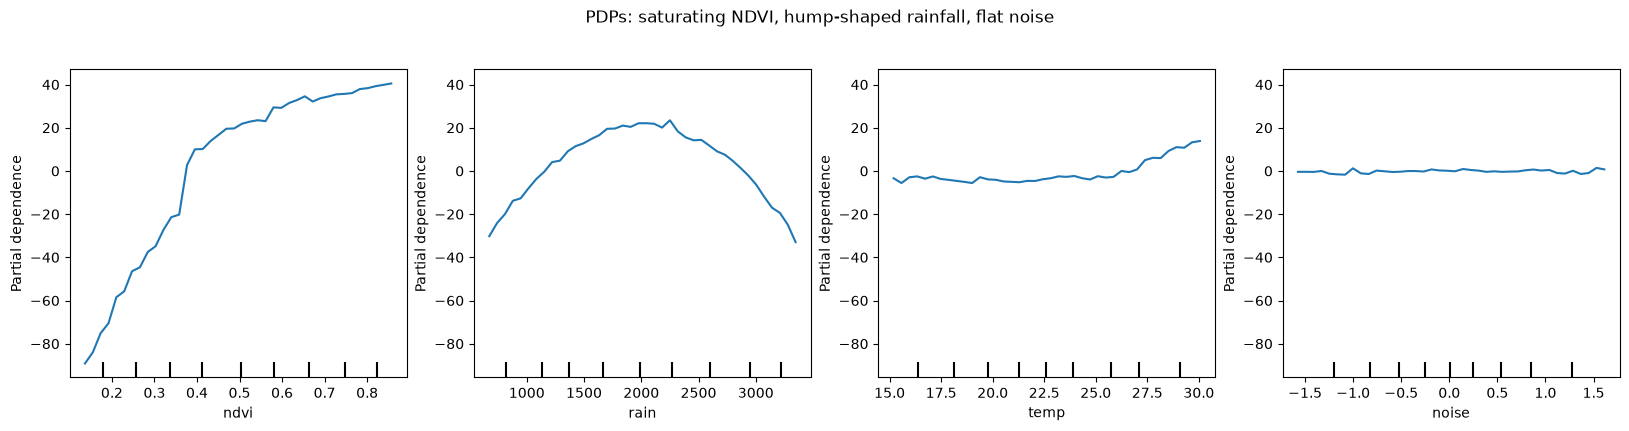

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
PartialDependenceDisplay.from_estimator(model, X_te, ["ndvi", "rain", "temp", "noise"], ax=axes, kind="average", grid_resolution=40)
plt.suptitle("PDPs: saturating NDVI, hump-shaped rainfall, flat noise", y=1.03); plt.show()

## **4. ICE Curves: Individual Effects**
A PDP averages away heterogeneity. **ICE** draws one curve per sample. Diverging curves reveal **interactions**: here, temperature matters only for low-elevation plots.

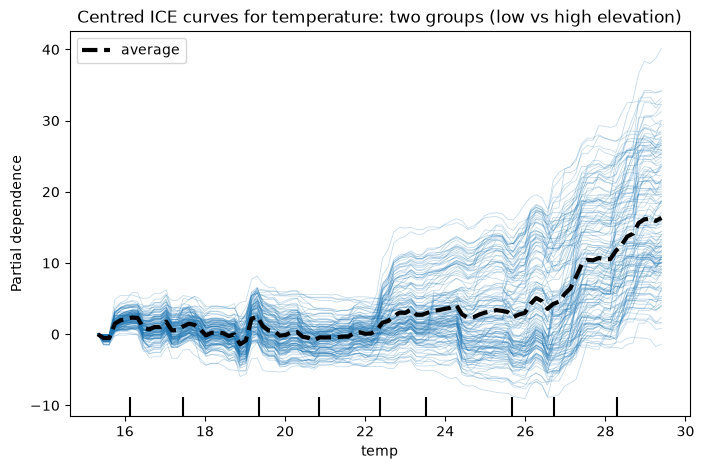

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sample = X_te.sample(150, random_state=0)
disp = PartialDependenceDisplay.from_estimator(model, sample, ["temp"], kind="both", centered=True, ax=ax,
                                               ice_lines_kw={"alpha": 0.3}, pd_line_kw={"color": "k", "lw": 3})
plt.title("Centred ICE curves for temperature: two groups (low vs high elevation)"); plt.show()

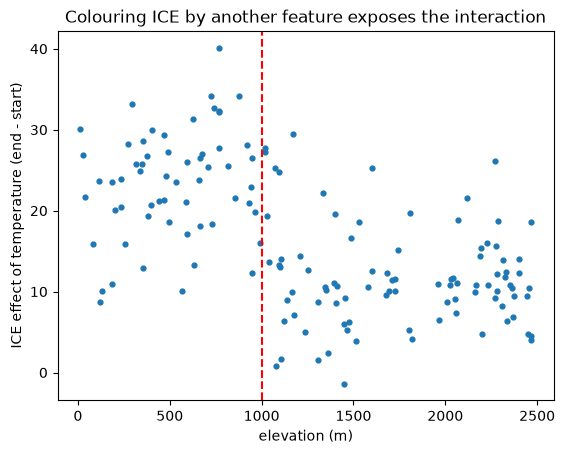

In [6]:
ice = partial_dependence(model, sample, ["temp"], kind="individual", grid_resolution=30)
slopes = ice["individual"][0][:, -1] - ice["individual"][0][:, 0]
plt.scatter(sample.elev, slopes, s=12); plt.axvline(1000, c="r", ls="--")
plt.xlabel("elevation (m)"); plt.ylabel("ICE effect of temperature (end - start)"); plt.title("Colouring ICE by another feature exposes the interaction"); plt.show()

## **5. The Problem With PDPs: Correlated Features**
To compute the PDP of NDVI at 0.9, the PDP pairs NDVI = 0.9 with **every** sample's canopy height, including 2 m-tall canopies that never occur with NDVI = 0.9. The model is evaluated **off the data manifold** (extrapolation), and the PDP can be misleading.

**Accumulated Local Effects (ALE)** (Apley & Zhu, 2020) fix this: within small intervals of $x_j$, compute the change in prediction when moving $x_j$ across the interval **only for samples that are actually in that interval**, then accumulate.

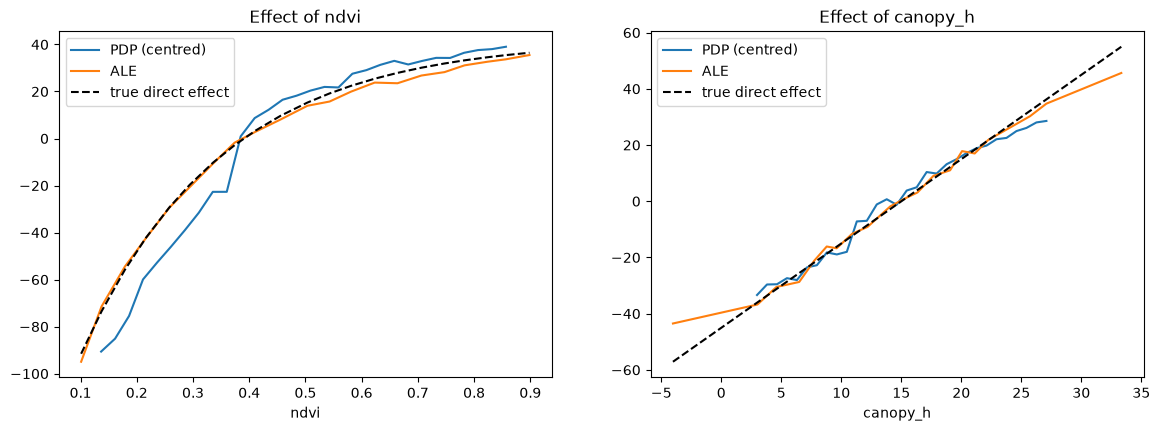

In [7]:
def ale_1d(model, X, feature, n_bins=20):
    x = X[feature].values
    edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    bin_idx = np.clip(np.digitize(x, edges[1:-1]), 0, len(edges) - 2)
    effects = np.zeros(len(edges) - 1); counts = np.zeros(len(edges) - 1)
    for k in range(len(edges) - 1):
        m = bin_idx == k
        if not m.any():
            continue
        lo, hi = X[m].copy(), X[m].copy()
        lo[feature] = edges[k]; hi[feature] = edges[k + 1]
        effects[k] = np.mean(model.predict(hi) - model.predict(lo)); counts[k] = m.sum()
    ale = np.r_[0, np.cumsum(effects)]
    centre = np.sum((ale[:-1] + ale[1:]) / 2 * counts) / counts.sum()            # centre so the mean effect is 0
    return edges, ale - centre

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, feat in zip(axes, ["ndvi", "canopy_h"]):
    pdp = partial_dependence(model, X_te, [feat], grid_resolution=30)
    grid = pdp["grid_values"][0]; ax.plot(grid, pdp["average"][0] - pdp["average"][0].mean(), label="PDP (centred)")
    e, a = ale_1d(model, X_te, feat); ax.plot(e, a, label="ALE")
    if feat == "ndvi":
        true = 200 * (1 - np.exp(-4 * e)); ax.plot(e, true - true.mean(), "k--", label="true direct effect")
    else:
        ax.plot(e, 3 * e - (3 * e).mean(), "k--", label="true direct effect")
    ax.set(title=f"Effect of {feat}", xlabel=feat); ax.legend()
plt.show()

### Two-way PDP: visualising an interaction

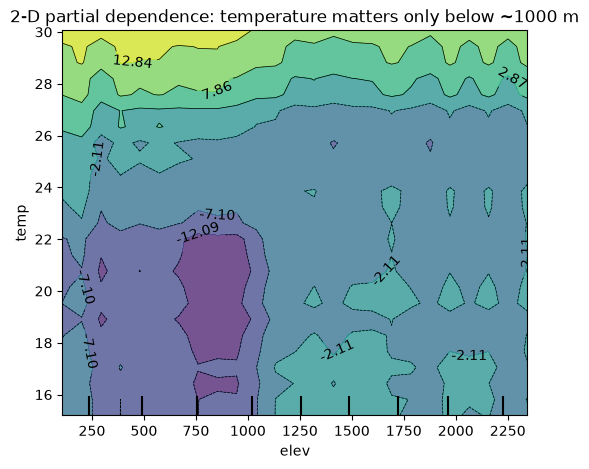

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(model, X_te, [("elev", "temp")], ax=ax, grid_resolution=25)
plt.title("2-D partial dependence: temperature matters only below ~1000 m"); plt.show()

### Friedman's H-statistic: how much of the effect is interaction?
$H^2_{jk}$ = share of the joint PD variance that is **not** explained by the sum of the individual PDs (0 = no interaction, 1 = pure interaction).

In [9]:
def h_statistic(model, X, f1, f2, n=300, seed=0):
    S = X.sample(n, random_state=seed)
    def pd_at(cols, vals):
        out = []
        for v in vals:
            Z = S.copy()
            for c, vv in zip(cols, v): Z[c] = vv
            out.append(model.predict(Z).mean())
        return np.array(out)
    pd12 = pd_at([f1, f2], S[[f1, f2]].values); pd1 = pd_at([f1], S[[f1]].values); pd2 = pd_at([f2], S[[f2]].values)
    pd12, pd1, pd2 = pd12 - pd12.mean(), pd1 - pd1.mean(), pd2 - pd2.mean()
    return np.sum((pd12 - pd1 - pd2) ** 2) / np.sum(pd12 ** 2)
for a, b in [("elev", "temp"), ("ndvi", "rain"), ("ndvi", "noise")]:
    print(f"H^2({a}, {b}) = {h_statistic(model, X_te, a, b):.3f}")

H^2(elev, temp) = 0.063


H^2(ndvi, rain) = 0.003


H^2(ndvi, noise) = 0.000


# **Part 2: Going Deeper - Pitfalls**

1. **Correlated features**: permutation importance and PDPs create unrealistic data points; importance is shared or distorted. Use ALE, grouped/conditional importance, or drop-column importance.
2. **Model explanations are not causal**: they describe what the **model** does, not what the world does. A feature can be important because it is a **proxy** for the real cause (Day 78).
3. **Overfitting explanations**: importance computed on training data rewards memorised noise (Day 33). Use held-out data.
4. **Uncertainty**: always show repeats/bootstrap intervals.

### Drop-column importance (the most honest, most expensive)

In [10]:
from sklearn.model_selection import cross_val_score
base_score = cross_val_score(HistGradientBoostingRegressor(max_iter=200, random_state=0), X, agb, cv=3).mean()
drop = {c: base_score - cross_val_score(HistGradientBoostingRegressor(max_iter=200, random_state=0), X.drop(columns=c), agb, cv=3).mean() for c in X.columns}
pd.DataFrame({"permutation (test)": pd.Series(pi.importances_mean, index=X.columns), "drop-column (CV)": pd.Series(drop)}).round(4).sort_values("drop-column (CV)", ascending=False)

,permutation (test),drop-column (CV)
rain,0.2083,0.1229
ndvi,0.8551,0.0859
canopy_h,0.2133,0.0259
temp,0.0308,0.0078
elev,0.0063,0.0011
noise,0.0003,0.0006


Dropping `canopy_h` costs less than permuting it: when the column is removed, the retrained model recovers much of the information from the correlated NDVI. Permutation measures **reliance of this model**; drop-column measures **unique contribution**.

## **Practice Problems**
1. Compute permutation importance on the **training** set and compare with the test set. Which features change most?
2. Draw ICE curves for `rain`. Is there heterogeneity?
3. Compute the ALE of `rain` and compare with its PDP. Are they similar here? Why (is rain correlated with other features)?
4. *(Advanced)* Make `canopy_h` almost identical to NDVI (noise sd 0.3). How do the PDP and ALE of NDVI change?

          train   test
ndvi      0.879  0.855
canopy_h  0.213  0.213
rain      0.218  0.208
elev      0.013  0.006
temp      0.036  0.031
noise     0.007  0.000


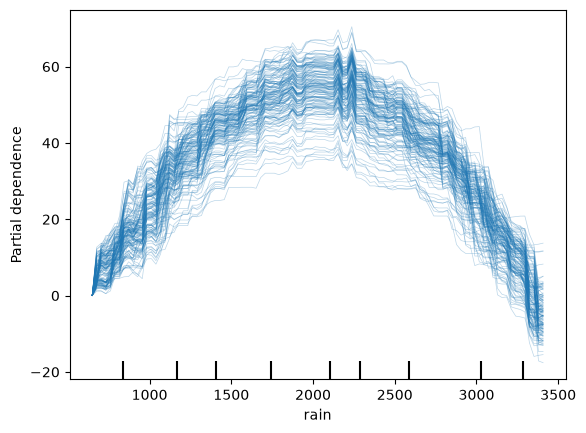

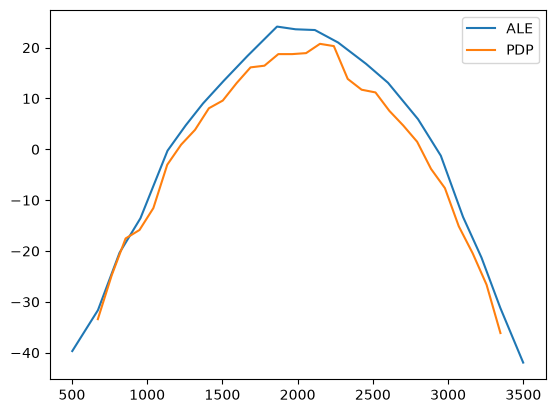

rain is independent of the other features -> PDP and ALE agree


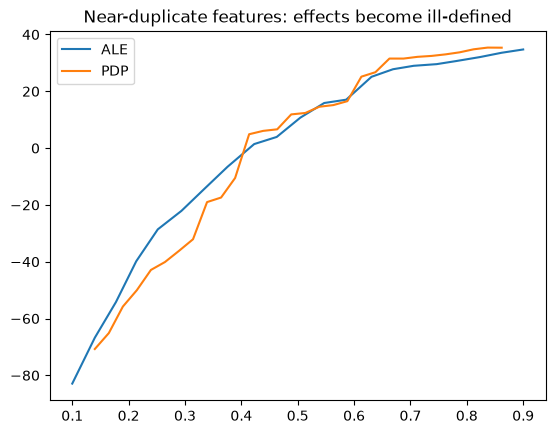

In [11]:
# Solution 1
pi_tr = permutation_importance(model, X_tr, y_tr, n_repeats=10, random_state=0, n_jobs=-1)
print(pd.DataFrame({"train": pi_tr.importances_mean, "test": pi.importances_mean}, index=X.columns).round(3))
# Solution 2
PartialDependenceDisplay.from_estimator(model, sample, ["rain"], kind="individual", centered=True, ice_lines_kw={"alpha": 0.3}); plt.show()
# Solution 3
e_r, a_r = ale_1d(model, X_te, "rain")
pdr = partial_dependence(model, X_te, ["rain"], grid_resolution=30)
plt.plot(e_r, a_r, label="ALE"); plt.plot(pdr["grid_values"][0], pdr["average"][0] - pdr["average"][0].mean(), label="PDP"); plt.legend(); plt.show()
print("rain is independent of the other features -> PDP and ALE agree")
# Solution 4
X2 = X.assign(canopy_h=30 * X.ndvi + rng.normal(0, 0.3, n))
y2 = 200 * (1 - np.exp(-4 * X2.ndvi)) + 3 * X2.canopy_h - 30 * ((X2.rain - 2000) / 1000) ** 2 + rng.normal(0, 10, n)
m2 = HistGradientBoostingRegressor(random_state=0).fit(X2, y2)
e2, a2 = ale_1d(m2, X2, "ndvi"); p2 = partial_dependence(m2, X2, ["ndvi"], grid_resolution=30)
plt.plot(e2, a2, label="ALE"); plt.plot(p2["grid_values"][0], p2["average"][0] - p2["average"][0].mean(), label="PDP"); plt.legend(); plt.title("Near-duplicate features: effects become ill-defined"); plt.show()

## **Key References**
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *The Annals of Statistics*, 29(5), 1189-1232 (PDP).
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). Peeking inside the black box: Visualizing statistical learning with plots of individual conditional expectation. *Journal of Computational and Graphical Statistics*, 24(1), 44-65.
- Apley, D. W., & Zhu, J. (2020). Visualizing the effects of predictor variables in black box supervised learning models. *Journal of the Royal Statistical Society B*, 82(4), 1059-1086.
- Friedman, J. H., & Popescu, B. E. (2008). Predictive learning via rule ensembles. *The Annals of Applied Statistics*, 2(3), 916-954 (H-statistic).
- Molnar, C. (2022). *Interpretable Machine Learning* (2nd ed.). christophm.github.io/interpretable-ml-book.
- Hooker, G., Mentch, L., & Zhou, S. (2021). Unrestricted permutation forces extrapolation: variable importance requires at least one more model, or there is no free variable importance. *Statistics and Computing*, 31, 82.